In [1]:
import pandas as pd
import re
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
data_path = "tweets-data\sentiment-italia.csv"
prepro_data_path = "tweets-data\hasilpreprocess-italia.csv"

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Asus\AppData\Local\Temp\ipykernel_2124\404684709.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_path = "tweets-data\sentiment-italia.csv"
C:\Users\Asus\AppData\Local\Temp\ipykernel_2124\404684709.py:2: SyntaxWarning: invalid escape sequence '\h'
  prepro_data_path = "tweets-data\hasilpreprocess-italia.csv"


In [3]:
data = pd.read_csv(data_path)

In [4]:
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1893729455157244084,Sun Feb 23 18:36:23 +0000 2025,0,@kenafricx21 Unaijua Manchester united anko?,1893731646622376172,NaN,kenafricx21,it,NaN,0,1,0,https://x.com/kasimuabuu98/status/189373164662...,1531168792507736064,kasimuabuu98
1,1893730064111382764,Sun Feb 23 18:30:05 +0000 2025,0,Unomudi mkomana ano support Manchester United ...,1893730064111382764,NaN,NaN,it,NaN,0,0,0,https://x.com/Suavefloew/status/18937300641113...,1867144816875692032,Suavefloew
2,1893728569970335962,Sun Feb 23 18:24:09 +0000 2025,0,Il Manchester United è la dimostrazione per cu...,1893728569970335962,NaN,NaN,it,Friuli-Venezia Giulia,0,0,0,https://x.com/Redblack100x100/status/189372856...,2333536199,Redblack100x100
3,1893723464587964540,Sun Feb 23 18:03:52 +0000 2025,0,Manchester United é DECIMO QUINTO colocado da ...,1893723464587964540,NaN,NaN,it,"Rua Mariano Procópio, 37",0,0,0,https://x.com/Leorz8/status/1893723464587964540,170414429,Leorz8
4,1893676632679821535,Sun Feb 23 17:35:31 +0000 2025,0,@JMariotz @miguuyamjeruman Manchester United u...,1893716329099624535,NaN,JMariotz,it,NaN,0,0,0,https://x.com/NovatyM27250/status/189371632909...,1699834656340996096,NovatyM27250


In [5]:
df = data[['full_text', 'username', 'created_at']]
df

,full_text,username,created_at
0,@kenafricx21 Unaijua Manchester united anko?,kasimuabuu98,Sun Feb 23 18:36:23 +0000 2025
1,Unomudi mkomana ano support Manchester United ...,Suavefloew,Sun Feb 23 18:30:05 +0000 2025
2,Il Manchester United è la dimostrazione per cu...,Redblack100x100,Sun Feb 23 18:24:09 +0000 2025
3,Manchester United é DECIMO QUINTO colocado da ...,Leorz8,Sun Feb 23 18:03:52 +0000 2025
4,@JMariotz @miguuyamjeruman Manchester United u...,NovatyM27250,Sun Feb 23 17:35:31 +0000 2025
...,...,...,...
562,@connectwithtola @nwabishop 1. Manchester Unit...,ChukwuebukaX002,Thu Feb 06 18:58:49 +0000 2025
563,@connectwithtola @nwabishop Manchester United ...,OkanlawonAyo,Thu Feb 06 18:56:21 +0000 2025
564,@connectwithtola @nwabishop Manchester United ...,MartinsUch51622,Thu Feb 06 18:46:06 +0000 2025
565,@connectwithtola @nwabishop Manchester United ...,Jennifer_Ezepue,Thu Feb 06 18:41:11 +0000 2025


# 1. Cleaning Data

In [6]:
df.shape

(567, 3)

In [7]:
df = df.drop_duplicates(subset=['full_text'])

In [8]:
df.duplicated().sum()

0

In [9]:
df = df.dropna()

In [10]:
df.isnull().sum()

full_text     0
username      0
created_at    0
dtype: int64

In [11]:
df.shape

(564, 3)

In [12]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^A-Za-z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['full_text'] = df['full_text'].apply(clean_twitter_text)

In [13]:
df['full_text'] = df['full_text'].str.lower()

In [14]:
df

,full_text,username,created_at
0,unaijua manchester united anko,kasimuabuu98,Sun Feb 23 18:36:23 +0000 2025
1,unomudi mkomana ano support manchester united ...,Suavefloew,Sun Feb 23 18:30:05 +0000 2025
2,il manchester united la dimostrazione per cui ...,Redblack100x100,Sun Feb 23 18:24:09 +0000 2025
3,manchester united decimo quinto colocado da pr...,Leorz8,Sun Feb 23 18:03:52 +0000 2025
4,manchester united usiseme kidogo ni unaiongele...,NovatyM27250,Sun Feb 23 17:35:31 +0000 2025
...,...,...,...
562,1 manchester united 31 leicester city 2 como 0...,ChukwuebukaX002,Thu Feb 06 18:58:49 +0000 2025
563,manchester united 2 2 leicester city como 2 2 ...,OkanlawonAyo,Thu Feb 06 18:56:21 +0000 2025
564,manchester united 42 leicester como 22 juventus,MartinsUch51622,Thu Feb 06 18:46:06 +0000 2025
565,manchester united 2 vs 1 leicester city como 0...,Jennifer_Ezepue,Thu Feb 06 18:41:11 +0000 2025


# 2. Preprocessing

- Normalisasi
- Stopword
- Tokenize
- Stemming

In [15]:
# Normalisasi

norm = {
    "xché": "perché", "ke": "che", "cmq": "comunque", "qnd": "quando", "qnt": "quanto",
    "nn": "non", "xò": "però", "qlcs": "qualcosa", "qlcn": "qualcuno", "grz": "grazie",
    "x": "per", "dv": "dove", "tt": "tutto", "trp": "troppo", "tb": "anche",
    "sn": "sono", "sto apposto": "sto a posto", "gg": "giorno", "raga": "ragazzi", "raga'": "ragazzi",
    "nn c'è": "non c'è", "scs": "scusa", "scsate": "scusate", "pt": "punto", "kmq": "comunque", "pk": "perché", "dp": "dopo"
}

def normalisasi(str_text):
    for i in norm:
        str_text = str_text.replace(i, norm[i])
    return str_text

df['full_text'] = df['full_text'].apply(lambda x: normalisasi(x))
df

,full_text,username,created_at
0,unaijua manchester united anko,kasimuabuu98,Sun Feb 23 18:36:23 +0000 2025
1,unomudi mkomana ano support manchester united ...,Suavefloew,Sun Feb 23 18:30:05 +0000 2025
2,il manchester united la dimostrazione per cui ...,Redblack100x100,Sun Feb 23 18:24:09 +0000 2025
3,manchester united decimo quinto colocado da pr...,Leorz8,Sun Feb 23 18:03:52 +0000 2025
4,manchester united usiseme kidogo ni unaiongele...,NovatyM27250,Sun Feb 23 17:35:31 +0000 2025
...,...,...,...
562,1 manchester united 31 leicester city 2 como 0...,ChukwuebukaX002,Thu Feb 06 18:58:49 +0000 2025
563,manchester united 2 2 leicester city como 2 2 ...,OkanlawonAyo,Thu Feb 06 18:56:21 +0000 2025
564,manchester united 42 leicester como 22 juventus,MartinsUch51622,Thu Feb 06 18:46:06 +0000 2025
565,manchester united 2 vs 1 leicester city como 0...,Jennifer_Ezepue,Thu Feb 06 18:41:11 +0000 2025


In [16]:
# Stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

manual_stop_words = [
    "ad", "al", "allo", "ai", "agli", "all", "agl", "alla", "alle", "con", "col", "coi",
    "da", "dal", "dallo", "dai", "dagli", "dall", "dagl", "dalla", "dalle", "di", "del",
    "dello", "dei", "degli", "dell", "degl", "della", "delle", "in", "nel", "nello", "nei",
    "negli", "nell", "negl", "nella", "nelle", "su", "sul", "sullo", "sui", "sugli", "sull",
    "sugl", "sulla", "sulle", "per", "tra", "fra", "il", "lo", "la", "i", "gli", "le", "l",
    "un", "uno", "una", "ma", "ed", "se", "perché", "anche", "come", "dove", "quando", "quanto",
    "quanta", "quanti", "quante", "chi", "cui", "non", "più", "meno", "molto", "tanto", "troppo",
    "poco", "ci", "ne", "mi", "ti", "si", "vi", "ci", "loro", "mio", "mia", "miei", "mie",
    "tuo", "tua", "tuoi", "tue", "suo", "sua", "suoi", "sue", "nostro", "nostra", "nostri",
    "nostre", "vostro", "vostra", "vostri", "vostre", "gli", "le", "loro", "questo", "questa",
    "questi", "queste", "quello", "quella", "quelli", "quelle", "ciò", "quindi", "perciò",
    "tuttavia", "infatti", "ovvero", "ossia", "cioè", "eppure"
]

nltk_stop_words = set(stopwords.words('italian'))
custom_stop_words = nltk_stop_words.union(set(manual_stop_words))

def remove_stopwords_manual(str_text):
    words = str_text.split()
    filtered_words = [word for word in words if word.lower() not in manual_stop_words]
    return " ".join(filtered_words)

df['full_text'] = df['full_text'].apply(remove_stopwords_manual)

df[['full_text']]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,full_text
0,unaijua manchester united anko
1,unomudi mkomana ano support manchester united ...
2,manchester united dimostrazione milan basta sp...
3,manchester united decimo quinto colocado premi...
4,manchester united usiseme kidogo ni unaiongele...
...,...
562,1 manchester united 31 leicester city 2 como 0...
563,manchester united 2 2 leicester city como 2 2 ...
564,manchester united 42 leicester como 22 juventus
565,manchester united 2 vs 1 leicester city como 0...


In [17]:
# Tokenize
tokenized = df['full_text'].apply(lambda x:x.split())
tokenized

0                    [unaijua, manchester, united, anko]
1      [unomudi, mkomana, ano, support, manchester, u...
2      [manchester, united, dimostrazione, milan, bas...
3      [manchester, united, decimo, quinto, colocado,...
4      [manchester, united, usiseme, kidogo, ni, unai...
                             ...                        
562    [1, manchester, united, 31, leicester, city, 2...
563    [manchester, united, 2, 2, leicester, city, co...
564    [manchester, united, 42, leicester, como, 22, ...
565    [manchester, united, 2, vs, 1, leicester, city...
566    [manchester, united, 30, leicester, city, como...
Name: full_text, Length: 564, dtype: object

In [18]:
import nltk
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df['full_text'] = df['full_text'].apply(stemming)
tokenized.to_csv(prepro_data_path, index=False)
data = pd.read_csv(prepro_data_path, encoding='latin1')


# 3. Labeling

In [19]:
data

,full_text
0,"['unaijua', 'manchester', 'united', 'anko']"
1,"['unomudi', 'mkomana', 'ano', 'support', 'manc..."
2,"['manchester', 'united', 'dimostrazione', 'mil..."
3,"['manchester', 'united', 'decimo', 'quinto', '..."
4,"['manchester', 'united', 'usiseme', 'kidogo', ..."
...,...
559,"['1', 'manchester', 'united', '31', 'leicester..."
560,"['manchester', 'united', '2', '2', 'leicester'..."
561,"['manchester', 'united', '42', 'leicester', 'c..."
562,"['manchester', 'united', '2', 'vs', '1', 'leic..."


In [20]:
import preprocessor as p 
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('movie_reviews')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
data_tweet = list(data['full_text'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob(tweet)
    polaritas += analysis.polarity

    if analysis.sentiment.polarity > 0.0:
        total_positif +=1
        status.append('Positif')
    elif analysis.sentiment.polarity == 0.0:
        total_netral += 1
        status.append('Netral')
    else:
        total_negatif += 1
        status.append('Negatif')

    total += 1

print(f"Hasil Analisis Data :\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}")
print(f"\nTotal Data : {total}")

Hasil Analisis Data :
Positif = 59
Netral = 487
Negatif = 18

Total Data : 564


In [22]:
data['klasifikasi'] = status
data

,full_text,klasifikasi
0,"['unaijua', 'manchester', 'united', 'anko']",Netral
1,"['unomudi', 'mkomana', 'ano', 'support', 'manc...",Netral
2,"['manchester', 'united', 'dimostrazione', 'mil...",Positif
3,"['manchester', 'united', 'decimo', 'quinto', '...",Netral
4,"['manchester', 'united', 'usiseme', 'kidogo', ...",Netral
...,...,...
559,"['1', 'manchester', 'united', '31', 'leicester...",Netral
560,"['manchester', 'united', '2', '2', 'leicester'...",Netral
561,"['manchester', 'united', '42', 'leicester', 'c...",Netral
562,"['manchester', 'united', '2', 'vs', '1', 'leic...",Netral


# 4. Visualisasi

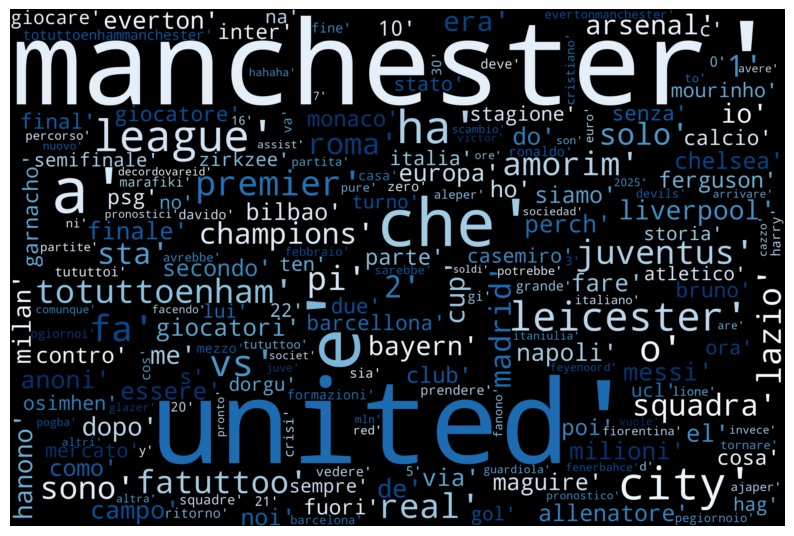

In [23]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
    plt.figure(figsize=(10,8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join([tweets for tweets in data['full_text']])

Wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(Wordcloud)

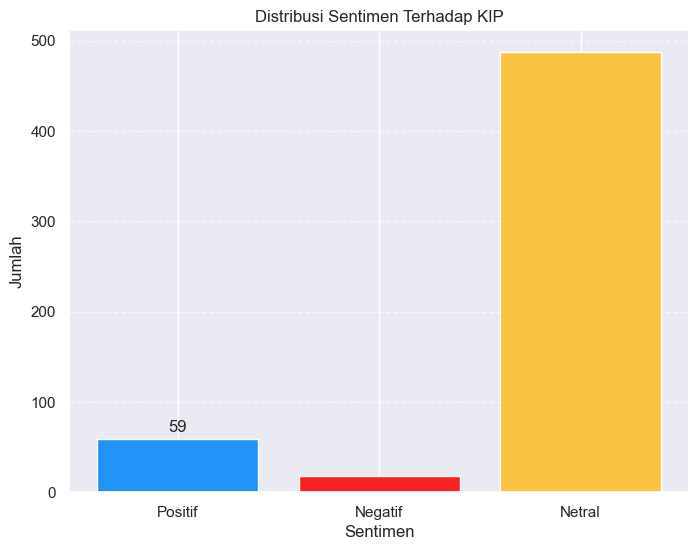

In [24]:
import seaborn as sns

sns.set_theme()

labels = ['Positif','Negatif','Netral']
counts =[total_positif,total_negatif,total_netral]

def show_bar_chart(labels, counts, title):
    fig, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, counts, color=['#2394f7','#f72323','#fac343'])

    for bar, count in zip(bars,counts):
        height = bar.get_height()
        ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        ax.set_xlabel('Sentimen')
        ax.set_ylabel('Jumlah')
        ax.set_title(title)

        plt.show()

show_bar_chart(labels,counts,"Distribusi Sentimen Terhadap KIP")

# 5. Multinomial Naive Bayes

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [26]:
data.head()

,full_text,klasifikasi
0,"['unaijua', 'manchester', 'united', 'anko']",Netral
1,"['unomudi', 'mkomana', 'ano', 'support', 'manc...",Netral
2,"['manchester', 'united', 'dimostrazione', 'mil...",Positif
3,"['manchester', 'united', 'decimo', 'quinto', '...",Netral
4,"['manchester', 'united', 'usiseme', 'kidogo', ...",Netral


In [27]:
data.shape

(564, 2)

In [28]:
data.klasifikasi.unique()

array(['Netral', 'Positif', 'Negatif'], dtype=object)

In [29]:
data.klasifikasi.value_counts()

klasifikasi
Netral     487
Positif     59
Negatif     18
Name: count, dtype: int64

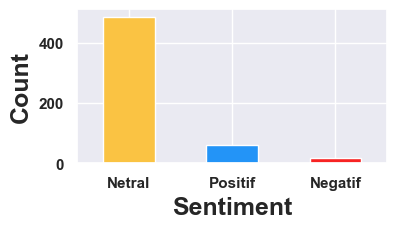

In [30]:
data.klasifikasi.value_counts().plot(kind='bar', figsize=(4, 2), rot=0, color=['#fac343', '#2394f7', '#f72323'])
plt.xlabel('Sentiment', fontweight='bold', fontsize=18)
plt.ylabel('Count', fontweight='bold', fontsize=18)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold');

In [31]:
labelencoder = LabelEncoder()
data['Target'] = labelencoder.fit_transform(data['klasifikasi'])

In [32]:
data.Target.unique()

array([1, 2, 0])

In [33]:
X = data.full_text
y = data.Target

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [35]:
len(X_train), len(X_test), len(y_train), len(y_test)

(451, 113, 451, 113)

In [36]:
clf = Pipeline([
    ('cv', CountVectorizer()),
    ('mnb', MultinomialNB(force_alpha=False))
])

In [37]:
clf.fit(X_train, y_train)

Pipeline(steps=[('cv', CountVectorizer()),
                ('mnb', MultinomialNB(force_alpha=False))])

In [38]:
print('Accuracy on the test set:', round(clf.score(X_test, y_test), 4))

Accuracy on the test set: 0.8761


In [39]:
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=clf.classes_)

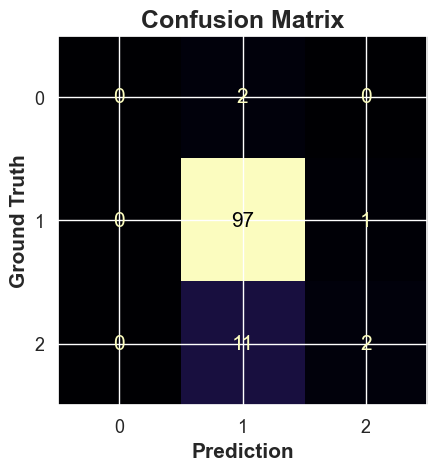

In [40]:

disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [41]:
cat_labels = ['negative', 'neutral', 'positive']
y_pred = clf.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=cat_labels)

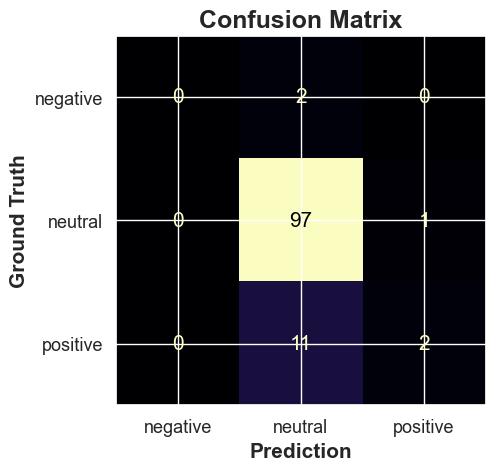

In [42]:
disp.plot(cmap='magma', colorbar=False, text_kw={'size': 15})

plt.xlabel('Prediction', fontsize=15, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=15, fontweight='bold')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13);

In [43]:
print('F1 score:', round(metrics.f1_score(y_test, y_pred, average='micro'), 4))

F1 score: 0.8761


In [44]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.88      0.99      0.93        98
           2       0.67      0.15      0.25        13

    accuracy                           0.88       113
   macro avg       0.52      0.38      0.39       113
weighted avg       0.84      0.88      0.84       113



c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

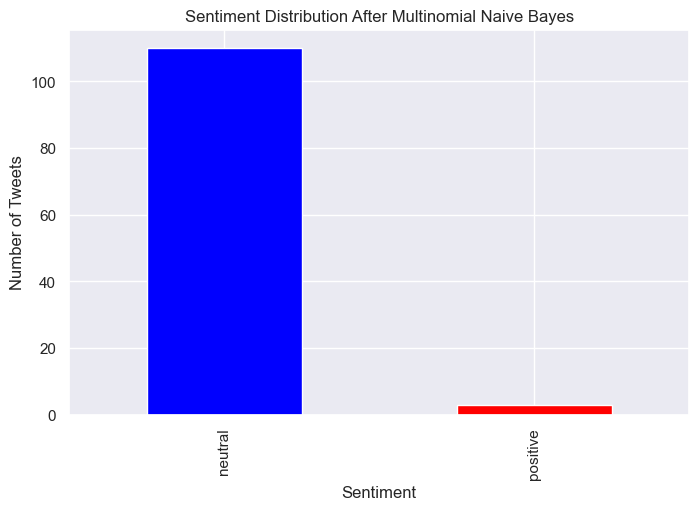

In [45]:
df_result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
df_result['Predicted'] = df_result['Predicted'].map(label_mapping)

sentiment_count = df_result['Predicted'].value_counts()

plt.figure(figsize=(8,5))
sentiment_count.plot(kind='bar', color=['blue', 'red', 'yellow'])
plt.title('Sentiment Distribution After Multinomial Naive Bayes')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()